# Análisis de Datos de Fútbol con StatsBomb

Exploración interactiva de competencias, partidos y eventos

## Paso 1: Explorar Competencias Disponibles

In [2]:
# Paso 1.1: Importar las librerías necesarias
from statsbombpy import sb  # API de StatsBomb para descargar datos
import pandas as pd  # Para trabajar con DataFrames
import warnings  # Para controlar avisos
warnings.filterwarnings('ignore')  # Ignorar avisos

In [3]:
# Paso 1.2: Descargar todas las competencias disponibles
competencias = sb.competitions()  # Descarga un DataFrame con todas las competencias

# Mostrar cuántas competencias tenemos
print(f"Total de competencias disponibles: {len(competencias)}")

Total de competencias disponibles: 75


In [4]:
# Paso 1.3: Ver qué columnas tenemos en el DataFrame
print("Columnas disponibles:")
print(competencias.columns.tolist())

Columnas disponibles:
['competition_id', 'season_id', 'country_name', 'competition_name', 'competition_gender', 'competition_youth', 'competition_international', 'season_name', 'match_updated', 'match_updated_360', 'match_available_360', 'match_available']


In [5]:
# Paso 1.4: Ver las primeras 5 filas del DataFrame
print("Primeras 5 competencias:")
competencias.head()

Primeras 5 competencias:


,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-07-06T04:26:07.636270,2025-07-06T04:26:07.636270,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,NaN,NaN,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2024-09-28T01:57:35.846538,NaN,NaN,2024-09-28T01:57:35.846538
3,16,4,Europe,Champions League,male,False,False,2018/2019,2025-05-08T15:10:50.835274,2021-06-13T16:17:31.694,NaN,2025-05-08T15:10:50.835274
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,NaN,2024-02-13T02:35:28.134882


In [6]:
# Paso 1.5: Seleccionar solo las columnas que nos importan
cols_importantes = ['competition_id', 'competition_name', 'season_name', 'country_name']  # Columnas de interés
df_limpio = competencias[cols_importantes].copy()  # Crear una copia con solo esas columnas

# Eliminar duplicados (misma competencia y temporada pueden aparecer varias veces)
df_limpio = df_limpio.drop_duplicates().reset_index(drop=True)

print(f"Competencias únicas: {len(df_limpio)}")
df_limpio.head(10)

Competencias únicas: 75


,competition_id,competition_name,season_name,country_name
0,9,1. Bundesliga,2023/2024,Germany
1,9,1. Bundesliga,2015/2016,Germany
2,1267,African Cup of Nations,2023,Africa
3,16,Champions League,2018/2019,Europe
4,16,Champions League,2017/2018,Europe
5,16,Champions League,2016/2017,Europe
6,16,Champions League,2015/2016,Europe
7,16,Champions League,2014/2015,Europe
8,16,Champions League,2013/2014,Europe
9,16,Champions League,2012/2013,Europe


In [7]:
# Paso 1.6: Contar competencias por país
competencias_por_pais = df_limpio['country_name'].value_counts()  # Contar cuántas competencias hay por país
print("Competencias disponibles por país:")
print(competencias_por_pais)

Competencias disponibles por país:
country_name
Europe                       23
Spain                        21
International                11
England                       5
France                        3
Germany                       2
Argentina                     2
United States of America      2
Italy                         2
Africa                        1
South America                 1
India                         1
North and Central America     1
Name: count, dtype: int64


## Paso 2: Descargar datos de una competencia específica

In [8]:
# Paso 2.1: Buscar la Premier League inglesa
# Vamos a ver todas las competencias y encontrar Premier League

# Mostrar todas las competencias únicas
print("Competencias disponibles:")
competencias_unicas = competencias[['competition_name', 'country_name']].drop_duplicates()
for idx, row in competencias_unicas.iterrows():
    print(f"  - {row['competition_name']} ({row['country_name']})")

print("\n" + "="*60)
print("Temporadas de Premier League:")
premier = competencias[competencias['competition_name'] == 'Premier League']
if len(premier) > 0:
    print(premier[['season_name', 'country_name']].drop_duplicates())
else:
    print("⚠️ No se encontró 'Premier League'")
    # Buscar variaciones del nombre
    print("\nBuscando variaciones...")
    for comp in competencias['competition_name'].unique():
        if 'premier' in comp.lower() or 'english' in comp.lower():
            print(f"  - {comp}")

Competencias disponibles:
  - 1. Bundesliga (Germany)
  - African Cup of Nations (Africa)
  - Champions League (Europe)
  - Copa America (South America)
  - Copa del Rey (Spain)
  - FA Women's Super League (England)
  - FIFA U20 World Cup (International)
  - FIFA World Cup (International)
  - Indian Super league (India)
  - La Liga (Spain)
  - Liga Profesional (Argentina)
  - Ligue 1 (France)
  - Major League Soccer (United States of America)
  - North American League (North and Central America)
  - NWSL (United States of America)
  - Premier League (England)
  - Serie A (Italy)
  - UEFA Euro (Europe)
  - UEFA Europa League (Europe)
  - UEFA Women's Euro (Europe)
  - Women's World Cup (International)

Temporadas de Premier League:
   season_name country_name
64   2015/2016      England
65   2003/2004      England


In [9]:
# Paso 2.2: Seleccionar una temporada específica de Premier League

# Primero, filtramos SOLO las filas de Premier League de England
premier_england = competencias[
    (competencias['competition_name'] == 'Premier League') &
    (competencias['country_name'] == 'England')
]

print("Filas de Premier League England encontradas:")
print(premier_england[['competition_id', 'season_id', 'competition_name', 'season_name', 'country_name']])

# Seleccionar la temporada 2015/2016
temporada_objetivo = '2015/2016'
fila_seleccionada = premier_england[premier_england['season_name'] == temporada_objetivo].iloc[0]

# Extraer el ID de competencia y temporada
comp_id = fila_seleccionada['competition_id']
season_id = fila_seleccionada['season_id']

print(f"\n✅ Competencia: {fila_seleccionada['competition_name']}")
print(f"✅ Temporada: {fila_seleccionada['season_name']}")
print(f"✅ País: {fila_seleccionada['country_name']}")
print(f"✅ Competition ID: {comp_id}")
print(f"✅ Season ID: {season_id}")

Filas de Premier League England encontradas:
    competition_id  season_id competition_name season_name country_name
64               2         27   Premier League   2015/2016      England
65               2         44   Premier League   2003/2004      England

✅ Competencia: Premier League
✅ Temporada: 2015/2016
✅ País: England
✅ Competition ID: 2
✅ Season ID: 27


## Paso 3: Descargar partidos

In [10]:
# CORRECCIÓN — Orden de celdas invertido (error 1/4):
# La celda original "3.1b" buscaba partidos ANTES de que la celda "3.1" los descargara.
# Al ejecutar el notebook de arriba hacia abajo, 'partidos' no existía y causaba
# NameError (o usaba datos de una sesión anterior, por eso el head() mostraba La Liga).
# Solución: esta celda ahora descarga los partidos primero (paso 3.1).

# Paso 3.1: Descargar partidos de Premier League 2015/2016
partidos = sb.matches(competition_id=comp_id, season_id=season_id)

print(f"Total de partidos descargados: {len(partidos)}")
print(f"\nVerificación:")
print(f"Competencia descargada: {partidos['competition_name'].iloc[0]}")
print(f"País: {partidos['competition_country_name'].iloc[0]}")
print(f"Temporada: {partidos['season'].iloc[0]}")

print(f"\nEquipos únicos:")
equipos = set(partidos['home_team'].unique()) | set(partidos['away_team'].unique())
print(sorted(equipos))

Total de partidos descargados: 380

Verificación:
Competencia descargada: Premier League
País: England
Temporada: 2015/2016

Equipos únicos:
['AFC Bournemouth', 'Arsenal', 'Aston Villa', 'Chelsea', 'Crystal Palace', 'Everton', 'Leicester City', 'Liverpool', 'Manchester City', 'Manchester United', 'Newcastle United', 'Norwich City', 'Southampton', 'Stoke City', 'Sunderland', 'Swansea City', 'Tottenham Hotspur', 'Watford', 'West Bromwich Albion', 'West Ham United']


In [11]:
# Continuación del reordenamiento (error 1/4):
# Este paso pasa a ser el 3.2 (antes llamado 3.1b).
# 'partidos' ya está disponible porque se descargó en la celda anterior.

# Paso 3.2: Buscar un partido específico (Manchester vs Liverpool)
partido_buscado = partidos[
    ((partidos['home_team'].str.contains('Manchester', case=False, na=False)) |
     (partidos['away_team'].str.contains('Manchester', case=False, na=False))) &
    ((partidos['home_team'].str.contains('Liverpool', case=False, na=False)) |
     (partidos['away_team'].str.contains('Liverpool', case=False, na=False)))
]

if len(partido_buscado) > 0:
    print(f"✅ Encontrados {len(partido_buscado)} partidos entre Manchester y Liverpool:")
    print(partido_buscado[['match_id', 'home_team', 'away_team', 'home_score', 'away_score', 'match_date']])
else:
    print("⚠️  No se encontró partido entre Manchester y Liverpool")
    print(f"\nTotal de partidos en la base de datos: {len(partidos)}")
    print("\nEquipos únicos disponibles:")
    equipos = set(partidos['home_team'].unique()) | set(partidos['away_team'].unique())
    for equipo in sorted(equipos):
        print(f"  - {equipo}")

✅ Encontrados 4 partidos entre Manchester y Liverpool:
     match_id          home_team          away_team  home_score  away_score  \
115   3754208    Manchester City          Liverpool           1           4   
172   3754003  Manchester United          Liverpool           3           1   
203   3753991          Liverpool    Manchester City           3           0   
369   3754345          Liverpool  Manchester United           0           1   

     match_date  
115  2015-11-21  
172  2015-09-12  
203  2016-03-02  
369  2016-01-17  


In [12]:
# Paso 3.3: Ver los primeros 5 partidos con información importante
cols_partidos = ['match_id', 'home_team', 'away_team', 'home_score', 'away_score', 'match_date']  # Columnas a mostrar (cambié 'date' por 'match_date')
print("Primeros 5 partidos:")
partidos[cols_partidos].head()  # Mostrar las primeras 5 filas

Primeros 5 partidos:


,match_id,home_team,away_team,home_score,away_score,match_date
0,3754058,Leicester City,AFC Bournemouth,0,0,2016-01-02
1,3754245,West Bromwich Albion,Sunderland,1,0,2015-10-17
2,3754136,Newcastle United,Aston Villa,1,1,2015-12-19
3,3754037,Everton,AFC Bournemouth,2,1,2016-04-30
4,3754039,Crystal Palace,Watford,1,2,2016-02-13


In [13]:
# Paso 3.4: Estadísticas básicas sobre los partidos
# ¿Cuántos goles se marcaron en total?
goles_totales = partidos['home_score'].sum() + partidos['away_score'].sum()  # Sumar todos los goles
promedio_goles = goles_totales / len(partidos)  # Calcular promedio

print(f"Total de goles en la temporada: {goles_totales}")
print(f"Promedio de goles por partido: {promedio_goles:.2f}")

Total de goles en la temporada: 1026
Promedio de goles por partido: 2.70


## Paso 4: Analizar eventos de un partido

In [14]:
# Paso 4.1: Seleccionar un partido de Manchester vs Liverpool para analizar eventos
# Usa el primero encontrado (puedes cambiar el índice [0] por otro si hay múltiples)

if len(partido_buscado) > 0:
    # Tomar el primer partido encontrado (cambia [0] por [1], [2], etc. si quieres otro)
    primer_partido = partido_buscado.iloc[0]  
    
    # Mostrar información del partido
    print(f"Partido seleccionado:")
    print(f"{primer_partido['home_team']} vs {primer_partido['away_team']}")
    print(f"Fecha: {primer_partido['match_date']}")
    print(f"Resultado: {int(primer_partido['home_score'])} - {int(primer_partido['away_score'])}")
    
    # Guardar el ID para descargar eventos
    match_id = primer_partido['match_id']  # ID del partido
    print(f"Match ID: {match_id}")
else:
    print("❌ No hay partido de Manchester vs Liverpool para analizar")
    print("Por favor, ejecuta la celda anterior para ver los partidos disponibles")

Partido seleccionado:
Manchester City vs Liverpool
Fecha: 2015-11-21
Resultado: 1 - 4
Match ID: 3754208


In [15]:
# Paso 4.2: Descargar todos los eventos del partido
# Esto puede tomar un momento...

eventos = sb.events(match_id=match_id)  # Descargar eventos del partido

# Ver cuántos eventos hay
print(f"Total de eventos en el partido: {len(eventos)}")

Total de eventos en el partido: 3720


In [16]:
# Paso 4.3: Ver qué tipos de eventos hay
print("Tipos de eventos en el partido:")
print(eventos['type'].value_counts())  # Contar eventos por tipo
print(f"\nTotal de tipos diferentes: {eventos['type'].nunique()}")

Tipos de eventos en el partido:
type
Pass                1027
Ball Receipt*        988
Carry                726
Pressure             361
Ball Recovery        127
Duel                  98
Clearance             74
Block                 47
Dispossessed          44
Dribble               36
Goal Keeper           29
Miscontrol            27
Dribbled Past         26
Shot                  26
Foul Committed        24
Foul Won              24
Interception           9
Substitution           6
Half Start             4
Half End               4
Starting XI            2
50/50                  2
Tactical Shift         2
Injury Stoppage        2
Shield                 1
Own Goal Against       1
Own Goal For           1
Bad Behaviour          1
Error                  1
Name: count, dtype: int64

Total de tipos diferentes: 29


In [17]:
# Paso 4.4: Contar eventos por equipo
# ¿Quién pasó más, tiró más o defendió más?

eventos_equipo = eventos['team'].value_counts()  # Contar eventos por equipo
print("Eventos por equipo:")
print(eventos_equipo)

Eventos por equipo:
team
Manchester City    2064
Liverpool          1656
Name: count, dtype: int64


In [18]:
# Paso 4.5: Analizar pases (Pass) de cada equipo
# Filtrar solo eventos de tipo "Pass"

pases = eventos[eventos['type'] == 'Pass']  # Solo pases
pases_por_equipo = pases['team'].value_counts()  # Contar pases por equipo

print("Pases completados por equipo:")
print(pases_por_equipo)

Pases completados por equipo:
team
Manchester City    610
Liverpool          417
Name: count, dtype: int64


In [19]:
import os
# Paso 4.6: Preparación — cada métrica se calcula en su propia celda
import matplotlib.pyplot as plt
os.makedirs('graficos', exist_ok=True)
import numpy as np

equipo1 = primer_partido['home_team']
equipo2 = primer_partido['away_team']

# Filtrar eventos por equipo una sola vez para reutilizar en cada celda
ev1 = eventos[eventos['team'] == equipo1]
ev2 = eventos[eventos['team'] == equipo2]

# Diccionario donde se acumula cada resultado
metricas = {equipo1: {}, equipo2: {}}

print(f"Equipos: {equipo1} vs {equipo2}")
print("Ejecuta cada celda siguiente para calcular cada métrica por separado.")

Equipos: Manchester City vs Liverpool
Ejecuta cada celda siguiente para calcular cada métrica por separado.


Total de Pases:  Manchester City: 610  |  Liverpool: 417


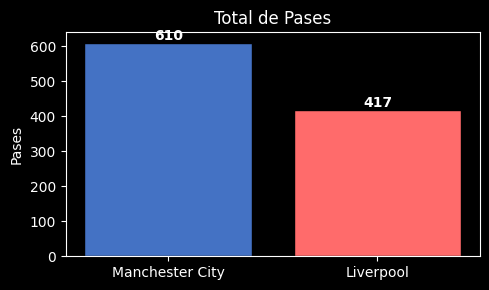

In [20]:
# Métrica 1/10 — Total de Pases

for equipo, ev in [(equipo1, ev1), (equipo2, ev2)]:
    metricas[equipo]['Total Pases'] = len(ev[ev['type'] == 'Pass'])

v1, v2 = metricas[equipo1]['Total Pases'], metricas[equipo2]['Total Pases']
print(f'Total de Pases:  {equipo1}: {v1}  |  {equipo2}: {v2}')

plt.close('all')  # evita acumulación de figuras entre celdas
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar([equipo1, equipo2], [v1, v2], color=['#4472C4','#FF6B6B'], edgecolor='black')
ax.bar_label(ax.containers[0], fontweight='bold')
ax.set_title('Total de Pases')
ax.set_ylabel('Pases')
plt.tight_layout()
os.makedirs('graficos', exist_ok=True)
plt.savefig('graficos/metrica_01_total_pases.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

Precisión de Pase:  Manchester City: 454 (74.4%)  |  Liverpool: 295 (70.7%)


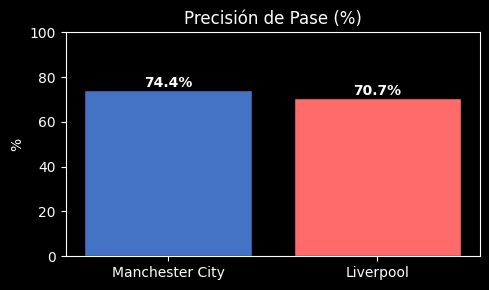

In [21]:
# Métrica 2/10 — Pases Completados y Precisión de Pase
# En StatsBomb, pass_outcome = NaN significa que el pase fue completado exitosamente

for equipo, ev in [(equipo1, ev1), (equipo2, ev2)]:
    pases = ev[ev['type'] == 'Pass']
    total = metricas[equipo]['Total Pases']
    completados = len(pases[pases['pass_outcome'].isna()])
    precision = round((completados / total * 100), 1) if total > 0 else 0
    metricas[equipo]['Pases Completados'] = completados
    metricas[equipo]['Precisión Pase (%)'] = precision

v1, v2 = metricas[equipo1]['Precisión Pase (%)'], metricas[equipo2]['Precisión Pase (%)']
print(f"Precisión de Pase:  {equipo1}: {metricas[equipo1]['Pases Completados']} ({v1}%)  |  {equipo2}: {metricas[equipo2]['Pases Completados']} ({v2}%)")

plt.close('all')
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar([equipo1, equipo2], [v1, v2], color=['#4472C4','#FF6B6B'], edgecolor='black')
ax.bar_label(ax.containers[0], fmt='%.1f%%', fontweight='bold')
ax.set_title('Precisión de Pase (%)')
ax.set_ylabel('%')
ax.set_ylim(0, 100)
plt.tight_layout()
os.makedirs('graficos', exist_ok=True)
plt.savefig('graficos/metrica_02_precision_pase.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

Tiros:  Manchester City: 12  |  Liverpool: 14


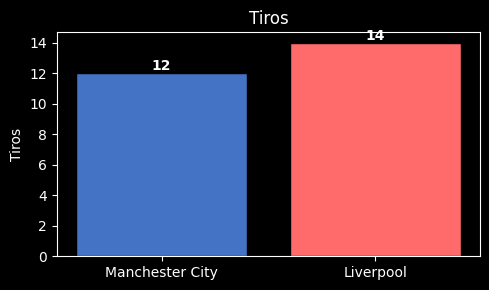

In [22]:
# Métrica 3/10 — Tiros

for equipo, ev in [(equipo1, ev1), (equipo2, ev2)]:
    metricas[equipo]['Tiros'] = len(ev[ev['type'] == 'Shot'])

v1, v2 = metricas[equipo1]['Tiros'], metricas[equipo2]['Tiros']
print(f'Tiros:  {equipo1}: {v1}  |  {equipo2}: {v2}')

plt.close('all')
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar([equipo1, equipo2], [v1, v2], color=['#4472C4','#FF6B6B'], edgecolor='black')
ax.bar_label(ax.containers[0], fontweight='bold')
ax.set_title('Tiros')
ax.set_ylabel('Tiros')
plt.tight_layout()
os.makedirs('graficos', exist_ok=True)
plt.savefig('graficos/metrica_03_tiros.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

Tiros a Puerta:  Manchester City: 1  |  Liverpool: 3


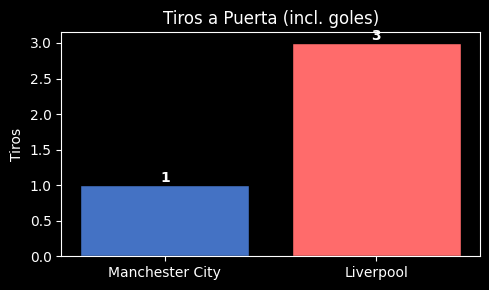

In [23]:
# Métrica 4/10 — Tiros a Puerta (incluye goles)
# En StatsBomb los goles tienen shot_outcome = 'Goal', no 'On Target'.
# Se incluyen ambos valores para no excluir los disparos que entraron.

for equipo, ev in [(equipo1, ev1), (equipo2, ev2)]:
    metricas[equipo]['Tiros a Puerta'] = len(
        ev[(ev['type'] == 'Shot') & (ev['shot_outcome'].isin(['On Target', 'Goal']))]
    )

v1, v2 = metricas[equipo1]['Tiros a Puerta'], metricas[equipo2]['Tiros a Puerta']
print(f'Tiros a Puerta:  {equipo1}: {v1}  |  {equipo2}: {v2}')

plt.close('all')
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar([equipo1, equipo2], [v1, v2], color=['#4472C4','#FF6B6B'], edgecolor='black')
ax.bar_label(ax.containers[0], fontweight='bold')
ax.set_title('Tiros a Puerta (incl. goles)')
ax.set_ylabel('Tiros')
plt.tight_layout()
os.makedirs('graficos', exist_ok=True)
plt.savefig('graficos/metrica_04_tiros_a_puerta.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

Posesión:  Manchester City: 55.5%  |  Liverpool: 44.5%


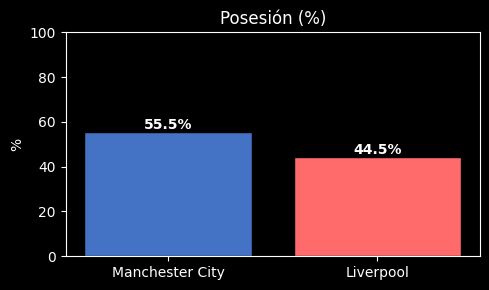

In [24]:
# Métrica 5/10 — Posesión (%)
# Se calcula como el porcentaje de eventos del partido que pertenecen a cada equipo

total_eventos = len(eventos)

for equipo, ev in [(equipo1, ev1), (equipo2, ev2)]:
    metricas[equipo]['Posesión (%)'] = round((len(ev) / total_eventos) * 100, 1)

v1, v2 = metricas[equipo1]['Posesión (%)'], metricas[equipo2]['Posesión (%)']
print(f'Posesión:  {equipo1}: {v1}%  |  {equipo2}: {v2}%')

plt.close('all')
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar([equipo1, equipo2], [v1, v2], color=['#4472C4','#FF6B6B'], edgecolor='black')
ax.bar_label(ax.containers[0], fmt='%.1f%%', fontweight='bold')
ax.set_title('Posesión (%)')
ax.set_ylabel('%')
ax.set_ylim(0, 100)
plt.tight_layout()
os.makedirs('graficos', exist_ok=True)
plt.savefig('graficos/metrica_05_posesion.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

Recuperos de Balón:  Manchester City: 197  |  Liverpool: 291


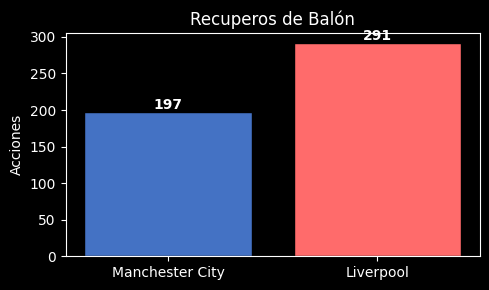

In [25]:
# Métrica 6/10 — Recuperos de Balón
# Suma presiones activas (Pressure) y recuperaciones directas (Ball Recovery)

for equipo, ev in [(equipo1, ev1), (equipo2, ev2)]:
    metricas[equipo]['Recuperos Balón'] = len(
        ev[(ev['type'] == 'Pressure') | (ev['type'] == 'Ball Recovery')]
    )

v1, v2 = metricas[equipo1]['Recuperos Balón'], metricas[equipo2]['Recuperos Balón']
print(f'Recuperos de Balón:  {equipo1}: {v1}  |  {equipo2}: {v2}')

plt.close('all')
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar([equipo1, equipo2], [v1, v2], color=['#4472C4','#FF6B6B'], edgecolor='black')
ax.bar_label(ax.containers[0], fontweight='bold')
ax.set_title('Recuperos de Balón')
ax.set_ylabel('Acciones')
plt.tight_layout()
os.makedirs('graficos', exist_ok=True)
plt.savefig('graficos/metrica_06_recuperos_balon.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

Duelos Ganados:  Manchester City: 3  |  Liverpool: 4


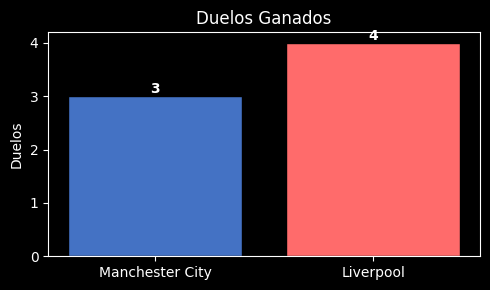

In [26]:
# Métrica 7/10 — Duelos Ganados

for equipo, ev in [(equipo1, ev1), (equipo2, ev2)]:
    metricas[equipo]['Duelos Ganados'] = len(
        ev[(ev['type'] == 'Duel') & (ev['duel_outcome'] == 'Won')]
    )

v1, v2 = metricas[equipo1]['Duelos Ganados'], metricas[equipo2]['Duelos Ganados']
print(f'Duelos Ganados:  {equipo1}: {v1}  |  {equipo2}: {v2}')

plt.close('all')
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar([equipo1, equipo2], [v1, v2], color=['#4472C4','#FF6B6B'], edgecolor='black')
ax.bar_label(ax.containers[0], fontweight='bold')
ax.set_title('Duelos Ganados')
ax.set_ylabel('Duelos')
plt.tight_layout()
os.makedirs('graficos', exist_ok=True)
plt.savefig('graficos/metrica_07_duelos_ganados.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

Intercepciones:  Manchester City: 4  |  Liverpool: 5


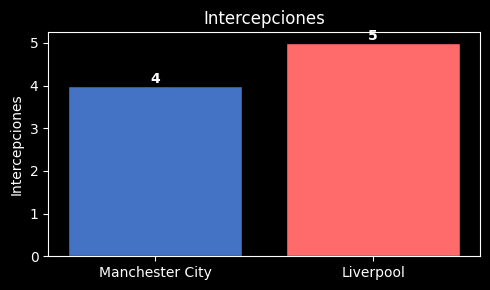

In [27]:
# Métrica 8/10 — Intercepciones

for equipo, ev in [(equipo1, ev1), (equipo2, ev2)]:
    metricas[equipo]['Intercepciones'] = len(ev[ev['type'] == 'Interception'])

v1, v2 = metricas[equipo1]['Intercepciones'], metricas[equipo2]['Intercepciones']
print(f'Intercepciones:  {equipo1}: {v1}  |  {equipo2}: {v2}')

plt.close('all')
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar([equipo1, equipo2], [v1, v2], color=['#4472C4','#FF6B6B'], edgecolor='black')
ax.bar_label(ax.containers[0], fontweight='bold')
ax.set_title('Intercepciones')
ax.set_ylabel('Intercepciones')
plt.tight_layout()
os.makedirs('graficos', exist_ok=True)
plt.savefig('graficos/metrica_08_intercepciones.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

Faltas Cometidas:  Manchester City: 11  |  Liverpool: 13


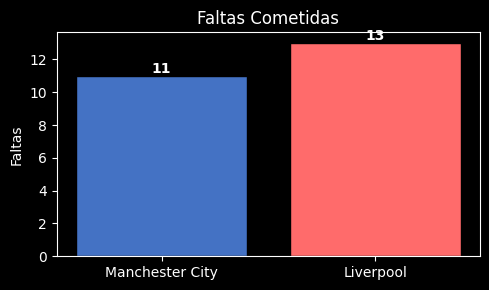

In [28]:
# Métrica 9/10 — Faltas Cometidas

for equipo, ev in [(equipo1, ev1), (equipo2, ev2)]:
    metricas[equipo]['Faltas Cometidas'] = len(ev[ev['type'] == 'Foul Committed'])

v1, v2 = metricas[equipo1]['Faltas Cometidas'], metricas[equipo2]['Faltas Cometidas']
print(f'Faltas Cometidas:  {equipo1}: {v1}  |  {equipo2}: {v2}')

plt.close('all')
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar([equipo1, equipo2], [v1, v2], color=['#4472C4','#FF6B6B'], edgecolor='black')
ax.bar_label(ax.containers[0], fontweight='bold')
ax.set_title('Faltas Cometidas')
ax.set_ylabel('Faltas')
plt.tight_layout()
os.makedirs('graficos', exist_ok=True)
plt.savefig('graficos/metrica_09_faltas_cometidas.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

Pases Largos (> 25 m):  Manchester City: 175  |  Liverpool: 108


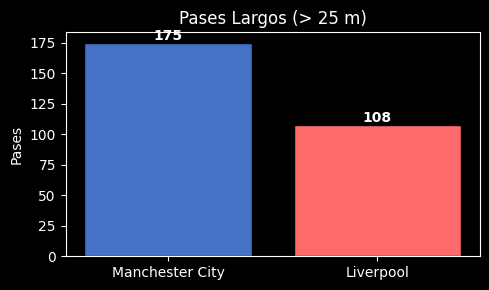

In [29]:
# Métrica 10/10 — Pases Largos (> 25 metros)
# Operación vectorizada con gt(25): evalúa toda la columna de una vez,
# más eficiente que recorrer fila por fila con iterrows()

for equipo, ev in [(equipo1, ev1), (equipo2, ev2)]:
    pases_df = ev[ev['type'] == 'Pass']
    metricas[equipo]['Pases Largos'] = int(pases_df['pass_length'].gt(25).sum())

v1, v2 = metricas[equipo1]['Pases Largos'], metricas[equipo2]['Pases Largos']
print(f'Pases Largos (> 25 m):  {equipo1}: {v1}  |  {equipo2}: {v2}')

plt.close('all')
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar([equipo1, equipo2], [v1, v2], color=['#4472C4','#FF6B6B'], edgecolor='black')
ax.bar_label(ax.containers[0], fontweight='bold')
ax.set_title('Pases Largos (> 25 m)')
ax.set_ylabel('Pases')
plt.tight_layout()
os.makedirs('graficos', exist_ok=True)
plt.savefig('graficos/metrica_10_pases_largos.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

In [30]:
# Resumen — DataFrame con todas las métricas calculadas

df_metricas = pd.DataFrame(metricas).T
print('='*80)
print('TOP 10 MÉTRICAS DEL PARTIDO')
print('='*80)
print(df_metricas.to_string())
print('='*80)

TOP 10 MÉTRICAS DEL PARTIDO
                 Total Pases  Pases Completados  Precisión Pase (%)  Tiros  Tiros a Puerta  Posesión (%)  Recuperos Balón  Duelos Ganados  Intercepciones  Faltas Cometidas  Pases Largos
Manchester City        610.0              454.0                74.4   12.0             1.0          55.5            197.0             3.0             4.0              11.0         175.0
Liverpool              417.0              295.0                70.7   14.0             3.0          44.5            291.0             4.0             5.0              13.0         108.0


In [31]:
# Paso 4.7: Resumen — ¿quién ganó en cada métrica?

metricas_principales = [
    'Total Pases', 'Precisión Pase (%)', 'Tiros', 'Tiros a Puerta',
    'Posesión (%)', 'Recuperos Balón', 'Duelos Ganados',
    'Intercepciones', 'Faltas Cometidas', 'Pases Completados'
]

print("\n" + "="*80)
print("ANÁLISIS COMPARATIVO - ¿QUIÉN GANÓ EN CADA MÉTRICA?")
print("="*80 + "\n")

ganador_por_metrica = {}

for metrica in metricas_principales:
    valor1 = df_metricas.loc[equipo1, metrica]
    valor2 = df_metricas.loc[equipo2, metrica]

    if valor1 > valor2:
        ganador, diferencia = equipo1, valor1 - valor2
    elif valor2 > valor1:
        ganador, diferencia = equipo2, valor2 - valor1
    else:
        ganador, diferencia = "Empate", 0

    ganador_por_metrica[metrica] = ganador

    if ganador != "Empate":
        print(f"📊 {metrica:.<30} {ganador} (+{diferencia:.1f})")
    else:
        print(f"📊 {metrica:.<30} {ganador}")

victorias_eq1 = sum(1 for v in ganador_por_metrica.values() if v == equipo1)
victorias_eq2 = sum(1 for v in ganador_por_metrica.values() if v == equipo2)
empates = sum(1 for v in ganador_por_metrica.values() if v == "Empate")

print("\n" + "="*80)
print("RESUMEN FINAL")
print("="*80)
print(f"🏆 {equipo1}: {victorias_eq1} métricas ganadas")
print(f"🏆 {equipo2}: {victorias_eq2} métricas ganadas")
print(f"🤝 Empates: {empates}")
print("\n💡 CONCLUSIÓN:")
if victorias_eq2 > victorias_eq1:
    print(f"   {equipo2} fue superior estadísticamente, lo que refleja su victoria 4-1")
else:
    print(f"   {equipo1} fue superior en posesión, pero {equipo2} fue más efectivo")
print("="*80)


ANÁLISIS COMPARATIVO - ¿QUIÉN GANÓ EN CADA MÉTRICA?

📊 Total Pases................... Manchester City (+193.0)
📊 Precisión Pase (%)............ Manchester City (+3.7)
📊 Tiros......................... Liverpool (+2.0)
📊 Tiros a Puerta................ Liverpool (+2.0)
📊 Posesión (%).................. Manchester City (+11.0)
📊 Recuperos Balón............... Liverpool (+94.0)
📊 Duelos Ganados................ Liverpool (+1.0)
📊 Intercepciones................ Liverpool (+1.0)
📊 Faltas Cometidas.............. Liverpool (+2.0)
📊 Pases Completados............. Manchester City (+159.0)

RESUMEN FINAL
🏆 Manchester City: 4 métricas ganadas
🏆 Liverpool: 6 métricas ganadas
🤝 Empates: 0

💡 CONCLUSIÓN:
   Liverpool fue superior estadísticamente, lo que refleja su victoria 4-1


## ¡Listo!

Ahora tienes un análisis paso a paso comentado. Puedes:
- Ejecutar cada celda de forma independiente
- Modificar los valores (temporada, competencia, etc.)
- Explorar más tipos de eventos
- Agregar más análisis según necesites

## Paso 5: Visualizaciones Avanzadas

Equipo                        xG   Goles Reales   Diferencia
------------------------------------------------------------
Manchester City             0.90              1        +0.10
Liverpool                   3.25              3        -0.25


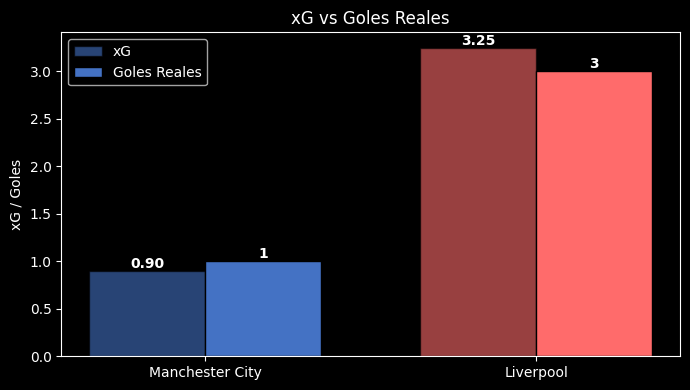

In [32]:
# Paso 5.1 — xG (Expected Goals)
# StatsBomb incluye 'shot_statsbomb_xg' en cada evento de tipo Shot.
# xG mide la probabilidad de que un tiro entre a gol (0 = imposible, 1 = seguro).
# La suma del xG indica cuántos goles 'merecía' marcar cada equipo.

tiros = eventos[eventos['type'] == 'Shot'].copy()

xg_por_equipo = tiros.groupby('team')['shot_statsbomb_xg'].sum().round(2)
goles_por_equipo = tiros[tiros['shot_outcome'] == 'Goal'].groupby('team').size()

print(f"{'Equipo':<25} {'xG':>6} {'Goles Reales':>14} {'Diferencia':>12}")
print('-' * 60)
for equipo in [equipo1, equipo2]:
    xg = xg_por_equipo.get(equipo, 0)
    goles = goles_por_equipo.get(equipo, 0)
    diff = goles - xg
    print(f'{equipo:<25} {xg:>6.2f} {goles:>14} {diff:>+12.2f}')

plt.close('all')
os.makedirs('graficos', exist_ok=True)
fig, ax = plt.subplots(figsize=(7, 4))

equipos_lista = [equipo1, equipo2]
xg_vals = [xg_por_equipo.get(e, 0) for e in equipos_lista]
goles_vals = [int(goles_por_equipo.get(e, 0)) for e in equipos_lista]

x = range(len(equipos_lista))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], xg_vals, width,
               label='xG', color=['#4472C4', '#FF6B6B'], alpha=0.6, edgecolor='black')
bars2 = ax.bar([i + width/2 for i in x], goles_vals, width,
               label='Goles Reales', color=['#4472C4', '#FF6B6B'], edgecolor='black')

ax.bar_label(bars1, fmt='%.2f', fontweight='bold')
ax.bar_label(bars2, fontweight='bold')
ax.set_xticks(list(x))
ax.set_xticklabels(equipos_lista)
ax.set_title('xG vs Goles Reales')
ax.set_ylabel('xG / Goles')
ax.legend()
plt.tight_layout()
plt.savefig('graficos/paso_51_xg.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

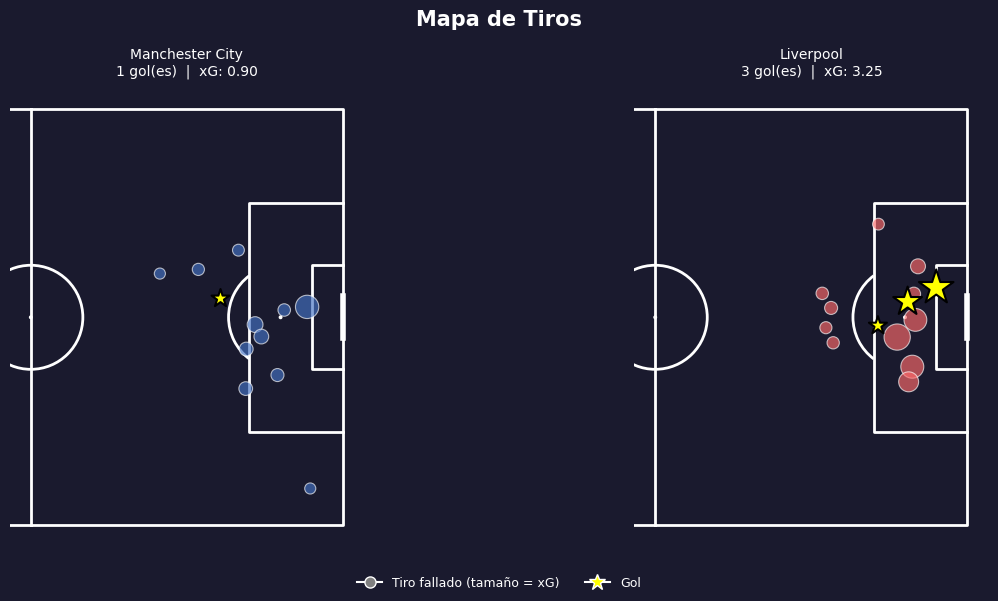

In [33]:
# Paso 5.2 — Mapa de Tiros
# Muestra desde dónde tiró cada equipo en el campo.
# Círculo = tiro fallado (tamaño proporcional al xG)
# Estrella amarilla = GOL
# Requiere: pip install mplsoccer

from mplsoccer import Pitch

tiros = eventos[eventos['type'] == 'Shot'].copy()
tiros['x'] = tiros['location'].apply(lambda loc: loc[0])
tiros['y'] = tiros['location'].apply(lambda loc: loc[1])
tiros['es_gol'] = tiros['shot_outcome'] == 'Goal'

plt.close('all')
os.makedirs('graficos', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#1a1a2e')
fig.suptitle('Mapa de Tiros', fontsize=15, fontweight='bold', color='white')

colores_equipo = {equipo1: '#4472C4', equipo2: '#FF6B6B'}

for ax, equipo in zip(axes, [equipo1, equipo2]):
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#1a1a2e',
                  line_color='white', half=True)
    pitch.draw(ax=ax)

    tiros_eq = tiros[tiros['team'] == equipo]

    # Tiros que no fueron gol
    fallados = tiros_eq[~tiros_eq['es_gol']]
    ax.scatter(
        fallados['x'], fallados['y'],
        s=fallados['shot_statsbomb_xg'] * 600 + 60,
        color=colores_equipo[equipo], alpha=0.65,
        edgecolors='white', linewidths=0.8, zorder=3
    )

    # Goles
    goles = tiros_eq[tiros_eq['es_gol']]
    ax.scatter(
        goles['x'], goles['y'],
        s=goles['shot_statsbomb_xg'] * 600 + 150,
        color='yellow', edgecolors='black',
        linewidths=1.5, marker='*', zorder=4
    )

    total_xg = tiros_eq['shot_statsbomb_xg'].sum()
    n_goles = int(tiros_eq['es_gol'].sum())
    ax.set_title(
        f'{equipo}\n{n_goles} gol(es)  |  xG: {total_xg:.2f}',
        fontsize=10, color='white', pad=10
    )

# Leyenda manual
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markersize=8, label='Tiro fallado (tamaño = xG)'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='yellow',
           markersize=12, label='Gol'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           frameon=False, fontsize=9, labelcolor='white')

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig('graficos/paso_52_mapa_tiros.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
plt.close()

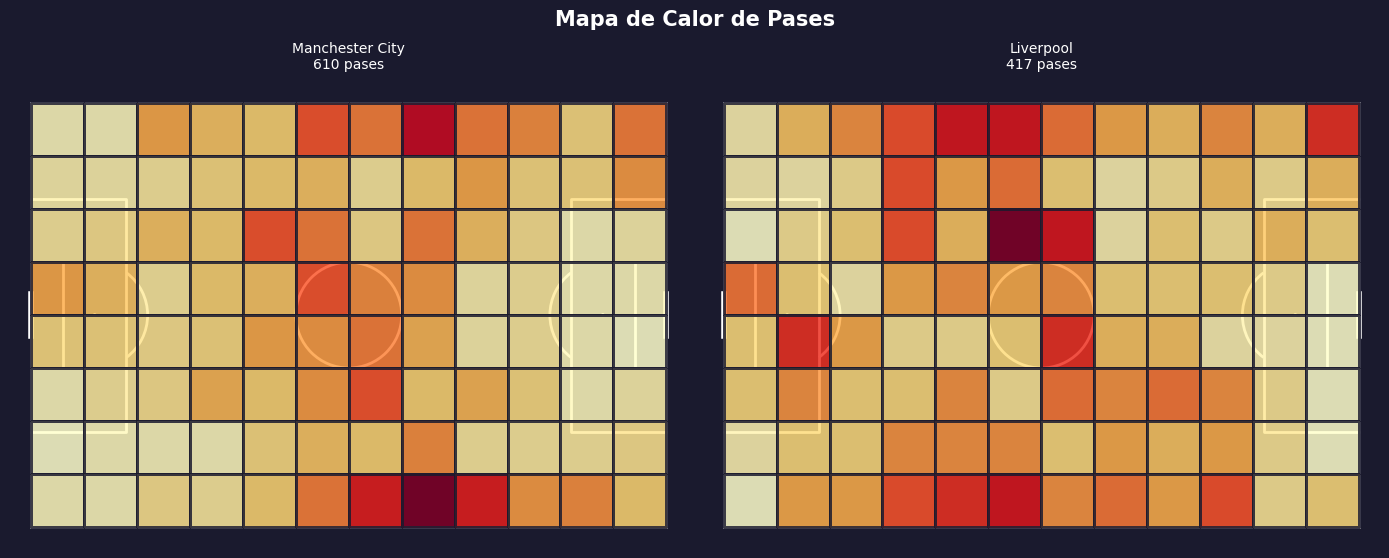

In [34]:
# Paso 5.3 — Mapa de Calor de Pases
# Muestra en qué zonas del campo se concentraron los pases de cada equipo.
# Las zonas más rojas/brillantes indican mayor actividad.

from mplsoccer import Pitch
import numpy as np

plt.close('all')
os.makedirs('graficos', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#1a1a2e')
fig.suptitle('Mapa de Calor de Pases', fontsize=15, fontweight='bold', color='white')

for ax, equipo in zip(axes, [equipo1, equipo2]):
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#1a1a2e', line_color='white')
    pitch.draw(ax=ax)

    pases_eq = eventos[(eventos['team'] == equipo) & (eventos['type'] == 'Pass')].copy()
    pases_eq['x'] = pases_eq['location'].apply(lambda loc: loc[0])
    pases_eq['y'] = pases_eq['location'].apply(lambda loc: loc[1])

    # Calcular heatmap con bins del campo
    bin_statistic = pitch.bin_statistic(
        pases_eq['x'], pases_eq['y'],
        statistic='count', bins=(12, 8)
    )
    # Normalizar para que el color sea relativo al propio equipo
    bin_statistic['statistic'] = (
        bin_statistic['statistic'] / bin_statistic['statistic'].max()
    )

    pitch.heatmap(bin_statistic, ax=ax, cmap='YlOrRd', edgecolors='#1a1a2e', alpha=0.85)

    total_pases = len(pases_eq)
    ax.set_title(
        f'{equipo}\n{total_pases} pases',
        fontsize=10, color='white', pad=10
    )

plt.tight_layout()
plt.savefig('graficos/paso_53_heatmap_pases.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
plt.close()

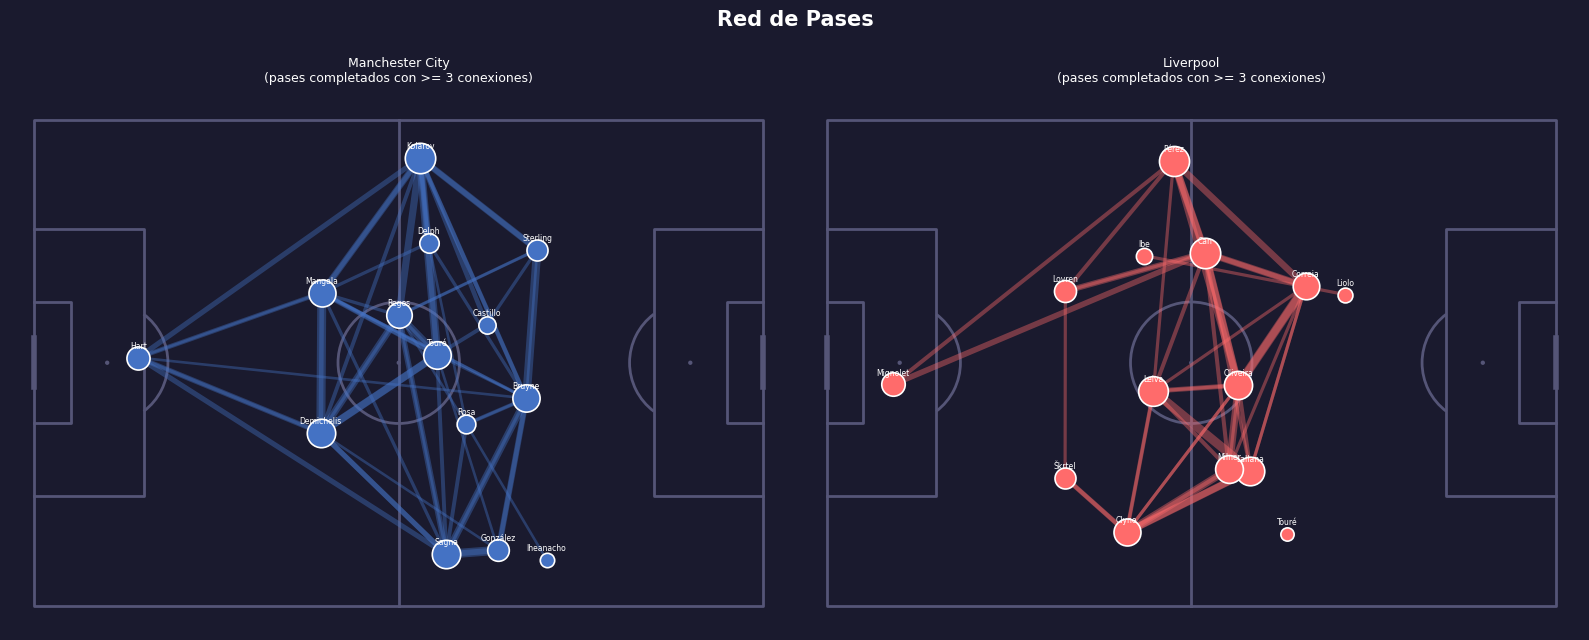

In [35]:
# Paso 5.4 — Red de Pases
# Muestra qué jugadores se pasaron entre sí y con qué frecuencia.
# Cada nodo = jugador (posición promedio en el partido)
# Grosor de línea = cantidad de pases entre ese par de jugadores

from mplsoccer import Pitch
from itertools import combinations

plt.close('all')
os.makedirs('graficos', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#1a1a2e')
fig.suptitle('Red de Pases', fontsize=15, fontweight='bold', color='white')

colores_equipo = {equipo1: '#4472C4', equipo2: '#FF6B6B'}

for ax, equipo in zip(axes, [equipo1, equipo2]):
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#1a1a2e', line_color='#555577')
    pitch.draw(ax=ax)

    # Solo pases completados (pass_outcome NaN = completado)
    pases_eq = eventos[
        (eventos['team'] == equipo) &
        (eventos['type'] == 'Pass') &
        (eventos['pass_outcome'].isna())
    ].copy()

    pases_eq['x'] = pases_eq['location'].apply(lambda l: l[0])
    pases_eq['y'] = pases_eq['location'].apply(lambda l: l[1])

    # Posición promedio de cada jugador
    pos_jugador = pases_eq.groupby('player')[['x', 'y']].mean()

    # Contar pases entre pares de jugadores
    pares = pases_eq.groupby(['player', 'pass_recipient']).size().reset_index(name='count')
    # Solo pares con al menos 3 pases para no saturar el gráfico
    pares = pares[pares['count'] >= 3]

    color = colores_equipo[equipo]
    max_count = pares['count'].max() if len(pares) > 0 else 1

    # Dibujar líneas de pases
    for _, row in pares.iterrows():
        if row['player'] in pos_jugador.index and row['pass_recipient'] in pos_jugador.index:
            x1, y1 = pos_jugador.loc[row['player'], ['x', 'y']]
            x2, y2 = pos_jugador.loc[row['pass_recipient'], ['x', 'y']]
            lw = (row['count'] / max_count) * 6 + 0.5
            ax.plot([x1, x2], [y1, y2], color=color, alpha=0.4, linewidth=lw, zorder=2)

    # Dibujar nodos de jugadores
    pases_por_jugador = pases_eq['player'].value_counts()
    for jugador, (x, y) in pos_jugador.iterrows():
        n = pases_por_jugador.get(jugador, 1)
        size = (n / pases_por_jugador.max()) * 400 + 80
        ax.scatter(x, y, s=size, color=color, edgecolors='white', linewidths=1.2, zorder=4)
        # Nombre abreviado: iniciales + apellido
        partes = jugador.split()
        nombre_corto = partes[-1] if len(partes) > 0 else jugador
        ax.annotate(nombre_corto, (x, y), textcoords='offset points',
                    xytext=(0, 7), ha='center', fontsize=5.5, color='white', zorder=5)

    ax.set_title(f'{equipo}\n(pases completados con >= 3 conexiones)',
                 fontsize=9, color='white', pad=10)

plt.tight_layout()
plt.savefig('graficos/paso_54_red_pases.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
plt.close()

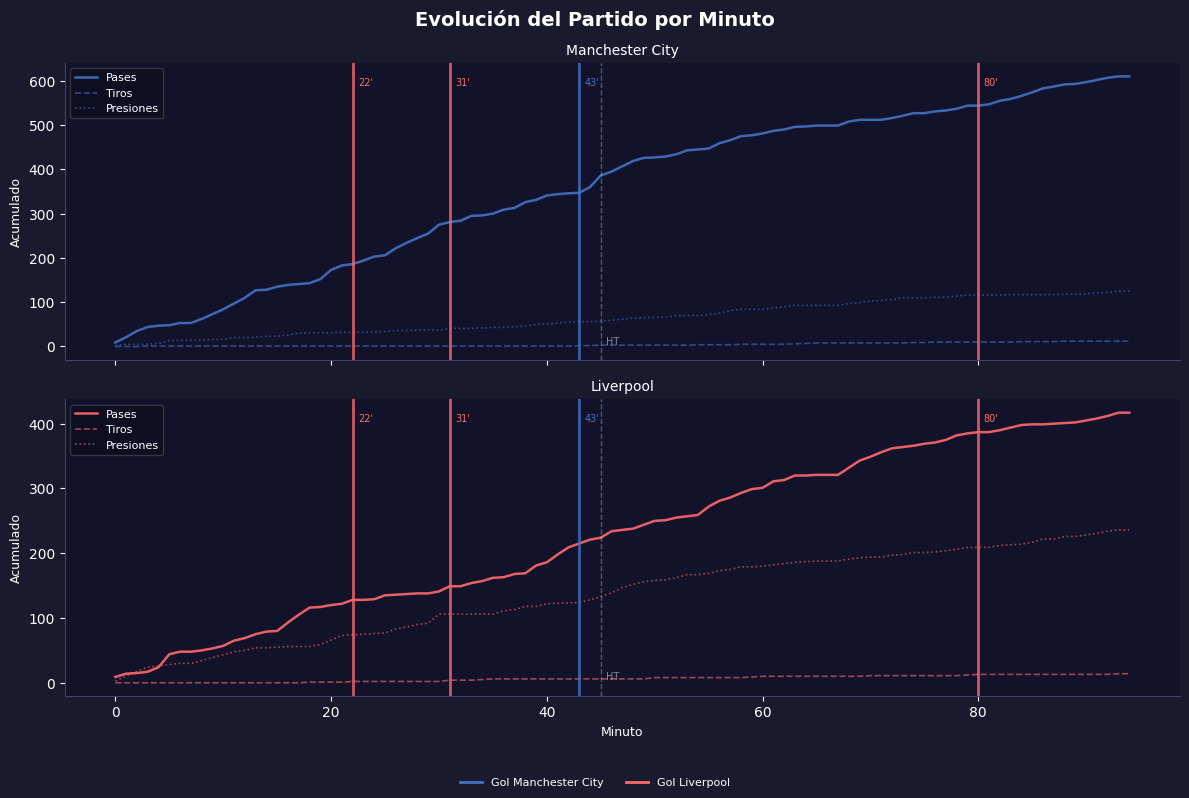

In [37]:
# Paso 5.5 — Evolución del Partido por Minuto
# Muestra cómo evolucionaron los pases acumulados de cada equipo a lo largo del partido.
# Los goles se marcan con líneas verticales para contextualizar momentos clave.

plt.close('all')
os.makedirs('graficos', exist_ok=True)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig.patch.set_facecolor('#1a1a2e')
fig.suptitle('Evolución del Partido por Minuto', fontsize=14, fontweight='bold', color='white')

colores_equipo = {equipo1: '#4472C4', equipo2: '#FF6B6B'}
tipos_a_graficar = ['Pass', 'Shot', 'Pressure']
labels = {'Pass': 'Pases', 'Shot': 'Tiros', 'Pressure': 'Presiones'}
estilos = {'Pass': '-', 'Shot': '--', 'Pressure': ':'}

# Goles del partido para marcar en el gráfico
goles_ev = eventos[
    (eventos['type'] == 'Shot') & (eventos['shot_outcome'] == 'Goal')
][['minute', 'team', 'player']].copy()

minuto_max = int(eventos['minute'].max())
minutos = range(0, minuto_max + 1)

for ax, equipo in zip(axes, [equipo1, equipo2]):
    ax.set_facecolor('#12122a')
    color = colores_equipo[equipo]
    ev_eq = eventos[eventos['team'] == equipo]

    for tipo in tipos_a_graficar:
        ev_tipo = ev_eq[ev_eq['type'] == tipo]
        # Acumulado por minuto
        conteo = ev_tipo.groupby('minute').size().reindex(minutos, fill_value=0).cumsum()
        ax.plot(conteo.index, conteo.values,
                color=color, linestyle=estilos[tipo],
                linewidth=1.8 if tipo == 'Pass' else 1.2,
                alpha=0.9 if tipo == 'Pass' else 0.6,
                label=labels[tipo])

    # Marcar goles con líneas verticales
    for _, gol in goles_ev.iterrows():
        c_gol = colores_equipo[gol['team']]
        ax.axvline(gol['minute'], color=c_gol, linewidth=2, alpha=0.8, linestyle='-')
        marcador = '⚽' if gol['team'] == equipo else ''
        ax.text(gol['minute'] + 0.5, ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else 10,
                f"{gol['minute']}'", fontsize=7, color=c_gol, va='top')

    # Marcar el descanso
    ax.axvline(45, color='white', linewidth=1, alpha=0.3, linestyle='--')
    ax.text(45.5, 5, 'HT', fontsize=7, color='white', alpha=0.5)

    ax.set_title(equipo, fontsize=10, color='white', pad=6)
    ax.set_ylabel('Acumulado', color='white', fontsize=9)
    ax.tick_params(colors='white')
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color('#444466')
    ax.legend(fontsize=8, framealpha=0.2, labelcolor='white', loc='upper left')

axes[-1].set_xlabel('Minuto', color='white', fontsize=9)

# Leyenda de goles
from matplotlib.lines import Line2D
leyenda_goles = [
    Line2D([0],[0], color=colores_equipo[equipo1], linewidth=2, label=f'Gol {equipo1}'),
    Line2D([0],[0], color=colores_equipo[equipo2], linewidth=2, label=f'Gol {equipo2}'),
]
fig.legend(handles=leyenda_goles, loc='lower center', ncol=2,
           frameon=False, fontsize=8, labelcolor='white')

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('graficos/paso_55_evolucion_partido.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
plt.close()

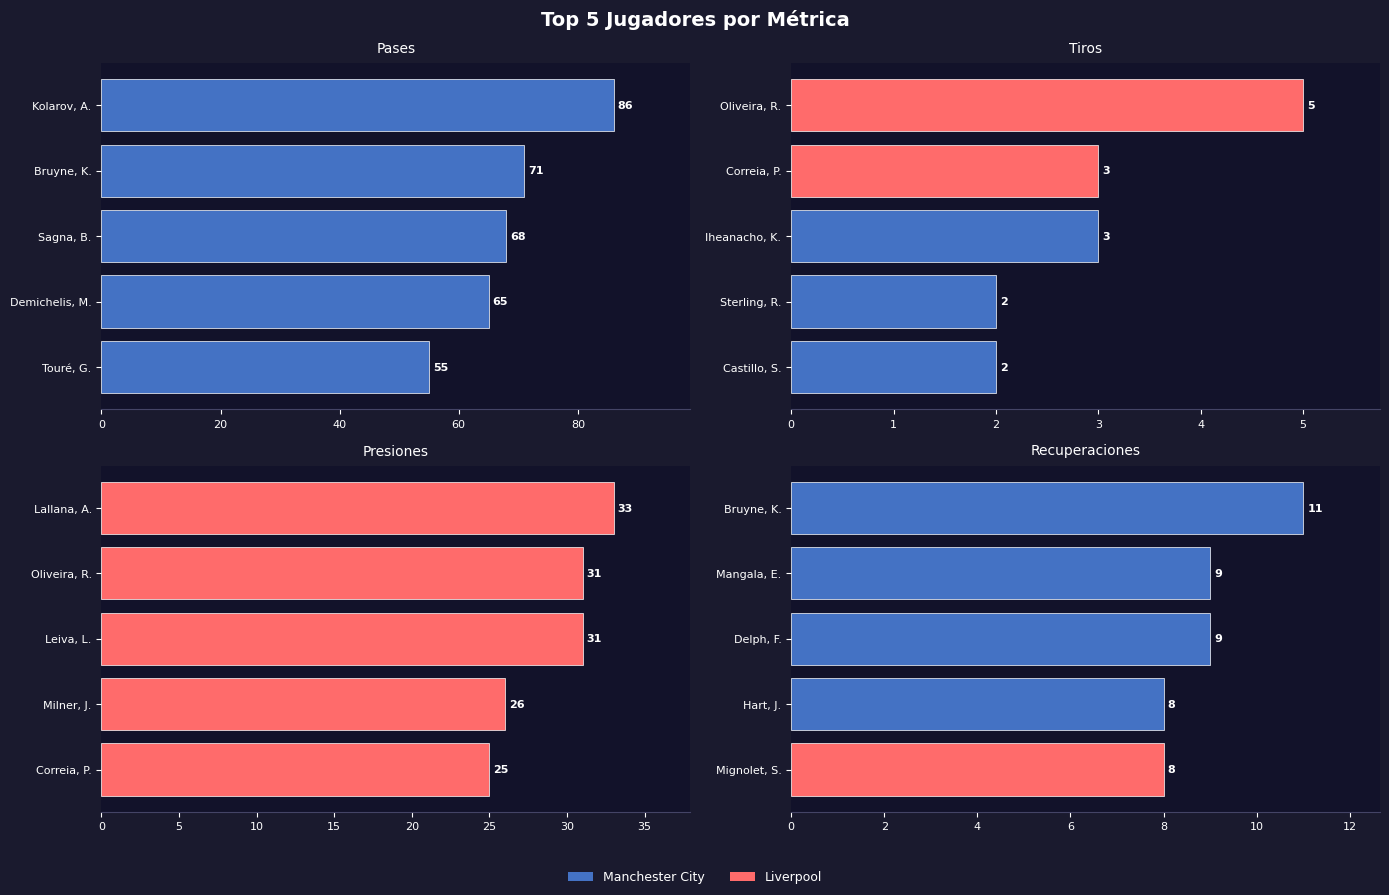

In [38]:
# Paso 5.6 — Top Jugadores por Métrica
# Ranking individual: top 5 por pases, tiros y presiones/recuperaciones.

plt.close('all')
os.makedirs('graficos', exist_ok=True)

metricas_jugador = [
    ('Pass',         'Pases',        None,       None),
    ('Shot',         'Tiros',        None,       None),
    ('Pressure',     'Presiones',    None,       None),
    ('Ball Recovery','Recuperaciones',None,      None),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.patch.set_facecolor('#1a1a2e')
fig.suptitle('Top 5 Jugadores por Métrica', fontsize=14, fontweight='bold', color='white')
axes = axes.flatten()

colores_equipo = {equipo1: '#4472C4', equipo2: '#FF6B6B'}

for ax, (tipo, titulo, _, __) in zip(axes, metricas_jugador):
    ax.set_facecolor('#12122a')

    ev_tipo = eventos[eventos['type'] == tipo][['player', 'team']].copy()
    top = ev_tipo['player'].value_counts().head(5)

    # Determinar color de cada jugador según su equipo
    colores_barra = []
    for jugador in top.index:
        equipo_jug = ev_tipo[ev_tipo['player'] == jugador]['team'].iloc[0]
        colores_barra.append(colores_equipo.get(equipo_jug, '#aaaaaa'))

    # Nombre abreviado
    nombres = [n.split()[-1] + ', ' + n.split()[0][0] + '.' if len(n.split()) > 1 else n
               for n in top.index]

    bars = ax.barh(nombres[::-1], top.values[::-1],
                   color=colores_barra[::-1], edgecolor='white', linewidth=0.5)
    ax.bar_label(bars, padding=3, color='white', fontsize=8, fontweight='bold')

    ax.set_title(titulo, color='white', fontsize=10, pad=8)
    ax.tick_params(colors='white', labelsize=8)
    ax.spines[['top','right','left']].set_visible(False)
    ax.spines['bottom'].set_color('#444466')
    ax.set_xlim(0, top.values.max() * 1.15)

# Leyenda de equipos
from matplotlib.patches import Patch
leyenda = [
    Patch(facecolor=colores_equipo[equipo1], label=equipo1),
    Patch(facecolor=colores_equipo[equipo2], label=equipo2),
]
fig.legend(handles=leyenda, loc='lower center', ncol=2,
           frameon=False, fontsize=9, labelcolor='white')

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('graficos/paso_56_top_jugadores.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
plt.close()

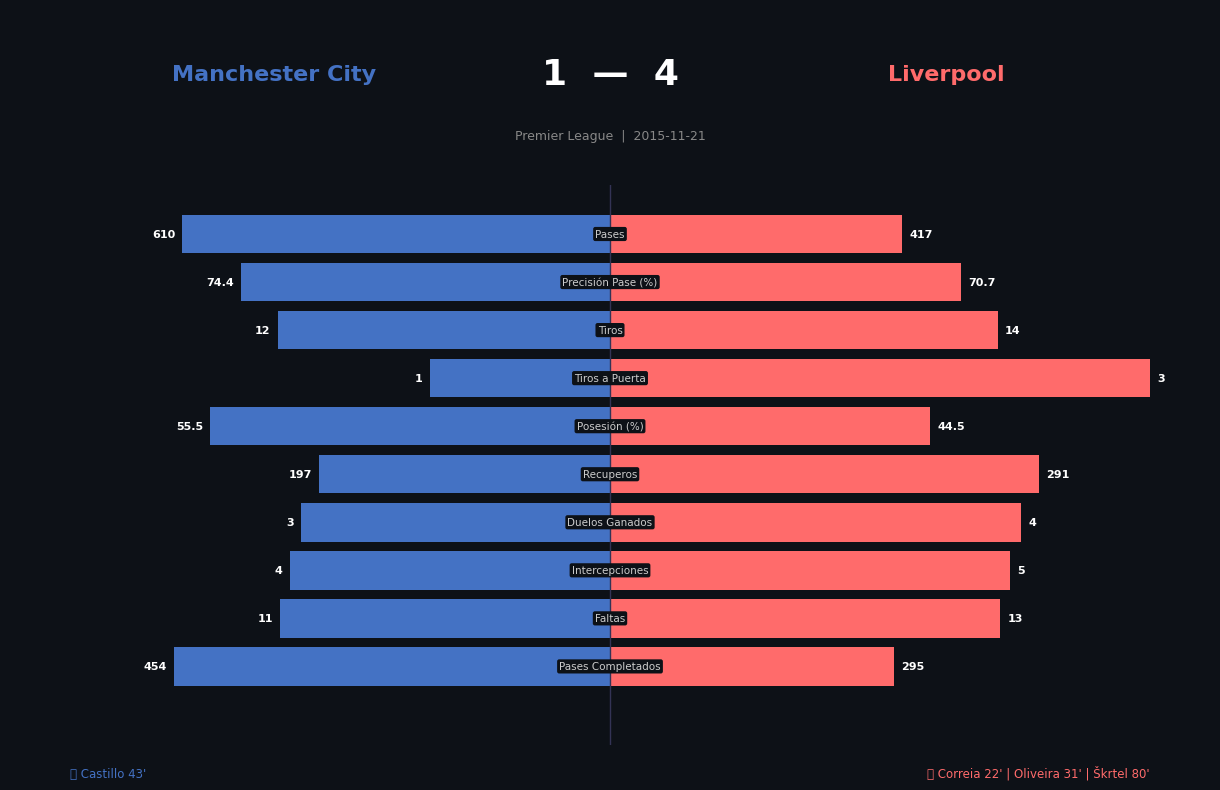


✅ Análisis completo. Todos los gráficos guardados en la carpeta graficos/


In [40]:
# Paso 5.7 — Tarjeta Resumen del Partido
# Una sola figura que resume el partido completo: marcador, métricas clave y goles.

plt.close('all')
os.makedirs('graficos', exist_ok=True)

c1, c2 = '#4472C4', '#FF6B6B'
bg = '#0d1117'

fig = plt.figure(figsize=(12, 8), facecolor=bg)

# ── Encabezado: marcador ──────────────────────────────────────────────
ax_header = fig.add_axes([0, 0.82, 1, 0.18], facecolor='#161b22')
ax_header.axis('off')

score1 = int(primer_partido['home_score'])
score2 = int(primer_partido['away_score'])
fecha  = primer_partido['match_date']

ax_header.text(0.22, 0.55, equipo1, ha='center', va='center',
               fontsize=16, fontweight='bold', color=c1, transform=ax_header.transAxes)
ax_header.text(0.50, 0.55, f'{score1}  —  {score2}', ha='center', va='center',
               fontsize=26, fontweight='bold', color='white', transform=ax_header.transAxes)
ax_header.text(0.78, 0.55, equipo2, ha='center', va='center',
               fontsize=16, fontweight='bold', color=c2, transform=ax_header.transAxes)
ax_header.text(0.50, 0.12, f'Premier League  |  {fecha}', ha='center', va='center',
               fontsize=9, color='#888888', transform=ax_header.transAxes)

# ── Métricas clave como barras horizontales enfrentadas ───────────────
ax_stats = fig.add_axes([0.05, 0.08, 0.90, 0.70], facecolor=bg)
ax_stats.axis('off')

metricas_resumen = [
    ('Total Pases',        'Pases'),
    ('Precisión Pase (%)', 'Precisión Pase (%)'),
    ('Tiros',              'Tiros'),
    ('Tiros a Puerta',     'Tiros a Puerta'),
    ('Posesión (%)',       'Posesión (%)'),
    ('Recuperos Balón',   'Recuperos'),
    ('Duelos Ganados',     'Duelos Ganados'),
    ('Intercepciones',     'Intercepciones'),
    ('Faltas Cometidas',   'Faltas'),
    ('Pases Completados',  'Pases Completados'),
]

n = len(metricas_resumen)
bar_height = 0.055
gap = (0.70 - n * bar_height) / (n + 1)

for i, (key, label) in enumerate(metricas_resumen):
    y = 0.68 - i * (bar_height + gap)
    v1 = float(df_metricas.loc[equipo1, key])
    v2 = float(df_metricas.loc[equipo2, key])
    total = v1 + v2 if (v1 + v2) > 0 else 1
    pct1 = v1 / total
    pct2 = v2 / total

    # Barra equipo1 (crece hacia la izquierda desde centro)
    ax_stats.barh(y, -pct1, left=0, height=bar_height,
                  color=c1, align='center')
    # Barra equipo2 (crece hacia la derecha)
    ax_stats.barh(y, pct2, left=0, height=bar_height,
                  color=c2, align='center')

    # Etiquetas de valor
    fmt = '{:.1f}' if isinstance(v1, float) and v1 != int(v1) else '{:.0f}'
    ax_stats.text(-pct1 - 0.01, y, fmt.format(v1),
                  ha='right', va='center', fontsize=8,
                  color='white', fontweight='bold')
    ax_stats.text(pct2 + 0.01, y, fmt.format(v2),
                  ha='left', va='center', fontsize=8,
                  color='white', fontweight='bold')
    # Etiqueta central
    ax_stats.text(0, y, label, ha='center', va='center',
                  fontsize=7.5, color='#cccccc',
                  bbox=dict(boxstyle='round,pad=0.2', fc=bg, ec='none'))

ax_stats.set_xlim(-0.75, 0.75)
ax_stats.set_ylim(-0.05, 0.75)
ax_stats.axvline(0, color='#333355', linewidth=1)

# Goles del partido en la parte inferior
goles_ev = eventos[
    (eventos['type'] == 'Shot') & (eventos['shot_outcome'] == 'Goal')
][['minute', 'team', 'player']].sort_values('minute')

goles_txt = []
for _, g in goles_ev.iterrows():
    apellido = g['player'].split()[-1]
    goles_txt.append((g['minute'], g['team'], apellido))

goles_eq1 = ' | '.join([f"{ap} {m}'" for m, t, ap in goles_txt if t == equipo1]) or '-'
goles_eq2 = ' | '.join([f"{ap} {m}'" for m, t, ap in goles_txt if t == equipo2]) or '-'

fig.text(0.05, 0.04, f'⚽ {goles_eq1}', ha='left', fontsize=8.5, color=c1)
fig.text(0.95, 0.04, f'⚽ {goles_eq2}', ha='right', fontsize=8.5, color=c2)

plt.savefig('graficos/paso_57_resumen_partido.png', dpi=150, bbox_inches='tight',
            facecolor=bg)
plt.show()
plt.close()
print('\n✅ Análisis completo. Todos los gráficos guardados en la carpeta graficos/')